In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"F:\CodeCave\Machine Learning\Datasets\Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
X = df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']].values
y = df['Species'].values

In [ ]:
from sklearn.preprocessing import LabelEncoder
# converting labels to numbers as in dataset we have labeled data in species column
le = LabelEncoder()
y = le.fit_transform(y)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
m, n = X_train.shape # example - (120,4) so here 120 samples and 4 features

# return unique labels as in dataset number of classes are 3 
num_classes = len(np.unique(y))

W = np.zeros((num_classes, n)) # here as each class has its own weight so here we write it like this 
b = np.zeros(num_classes) # one bias per class because bias is not tied to features

In [ ]:
# to convert model scores into probabilities
def softmax(z):
    # find maximum value in each row and then substarct maximun and then remaining will be return 
    # why substract max - to avoid numerical overflow
    # and after exponenial every number will be postive
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  
    # normalize values into probability 
    return exp_z / np.sum(exp_z, axis=1, keepdims=True) # keepdims means keep it as a column

In [ ]:
def compute_cost(X, y, W, b):
    m = X.shape[0]
    Z = np.dot(X, W.T) + b
    probs = softmax(Z) #probability 
    
    # this picks probability of correct class so low probability -> high penalty
    log_likelihood = -np.log(probs[range(m), y])
    return np.mean(log_likelihood) #this is cross entropy 

In [ ]:
learning_rate = 0.1
epochs = 1000

for i in range(epochs):
    Z = np.dot(X_train, W.T) + b
    probs = softmax(Z)

    #one hot encoding - instead of storing it as a number we represents it as a vector
    one_hot = np.zeros_like(probs) #this creates a matrix of zeros same shape as probs like suppose probs - (120,3) so matrix will be 120*3
    # place 1 at (ro1 - sample index and column- row index)
    one_hot[np.arange(len(y_train)), y_train] = 1  # by doing this each row will show the true class as a vector 
    

    # probability - one hot = error term
    dW = (1/m) * np.dot((probs - one_hot).T, X_train)
    db = (1/m) * np.sum(probs - one_hot, axis=0)

    W -= learning_rate * dW
    b -= learning_rate * db

    if i % 100 == 0:
        print("Cost after iteration", i, ":", compute_cost(X_train, y_train, W, b))

Cost after iteration 0 : 1.0091454095780334
Cost after iteration 100 : 0.3393885209969466
Cost after iteration 200 : 0.2700134857341599
Cost after iteration 300 : 0.22879839162980786
Cost after iteration 400 : 0.2007406245148292
Cost after iteration 500 : 0.18038079393274623
Cost after iteration 600 : 0.16494401916942844
Cost after iteration 700 : 0.1528431489894641
Cost after iteration 800 : 0.1431032044215805
Cost after iteration 900 : 0.13509307757632227


In [12]:
def predict(X, W, b):
    Z = np.dot(X, W.T) + b
    probs = softmax(Z)
    return np.argmax(probs, axis=1)

Test accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


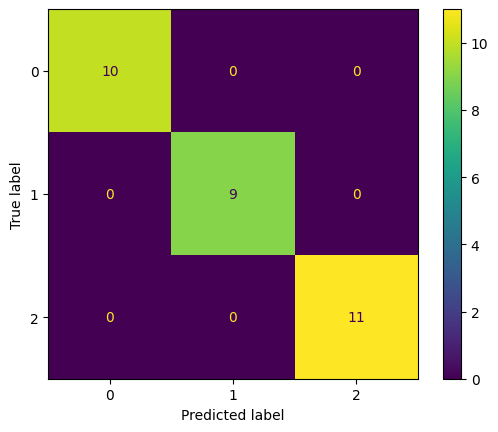

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
y_pred = predict(X_test, W, b)
print("Test accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [14]:
print("Train accuracy:", np.mean(predict(X_train,W,b)==y_train))
print("Test accuracy:", np.mean(predict(X_test,W,b)==y_test))

Train accuracy: 0.9666666666666667
Test accuracy: 1.0
